# Pipeline Moises — scriptCS_testing.m em Python

Carrega vídeo, remove DC, aplica Hilbert (X0, X90), PCA dual, Complexity Pursuit (BSS) e extrai formas modais e coordenadas modais. Funções em `src/moises`.

## Imports

In [4]:
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt


sys.path.insert(0, "src")

import moises
from moises.data import Video, load_video_dataset
# reload all submodules of moises
for name, module in list(sys.modules.items()):
    if name.startswith("moises"):
        importlib.reload(module)

## Parâmetros e carregamento do vídeo

In [ ]:
video_path = "matlab/Video 1 raw_400.avi"  # ajuste o caminho se necessário
max_frames = 400  # None = carregar todo o vídeo

video = Video(video_path, max_frames=max_frames)
video.load()

t = np.arange(video.frame_count) / video.fps
freq = np.arange(video.frame_count) * video.fps / video.frame_count

dataset, mean = load_video_dataset(video)


print(f"Dataset: {dataset.shape}, mean removido (DC).")



Loading video dataset...
Video shape: 216 384
Dataset: (400, 82944), mean removido (DC).


## Aumento de dados (Hilbert)

In [6]:
X0, X90 = moises.hilbert_augment(dataset)

## PCA dual (real + imaginário) e ordenação

In [7]:
[H0,W0,V0] = moises.pca(X0.T);
[H90,W90,V90] = moises.pca(X90.T);

In [8]:
V = np.concatenate([V0, V90])
idx = np.argsort(-V)
V = V[idx]

H = np.hstack([H0, H90])[:, idx]
W = np.hstack([W0, W90])[:, idx]

## Blind Source Separation (Complexity Pursuit)

In [9]:
num_pc = 16
unmixed, Wmix = moises.cp_alg(H[:, :num_pc])
Winvmix = np.flip(np.linalg.inv(Wmix), axis=0)
unmixed = -np.fliplr(unmixed)

## Formas modais e coordenadas modais

In [10]:
srcs = [0, 1, 8, 9, 13, 14]  # 1-based no MATLAB -> 0-based aqui
modal_coord, mode_shapes = moises.solve_modal(unmixed, Winvmix, W, srcs, num_pc=num_pc)
print("modal_coord (espacial):", modal_coord.shape, "— mode_shapes (temporal):", mode_shapes.shape)

modal_coord (espacial): (400, 6) — mode_shapes (temporal): (82944, 6)


## Visualização: fontes (sinais no tempo, PSD e fase)

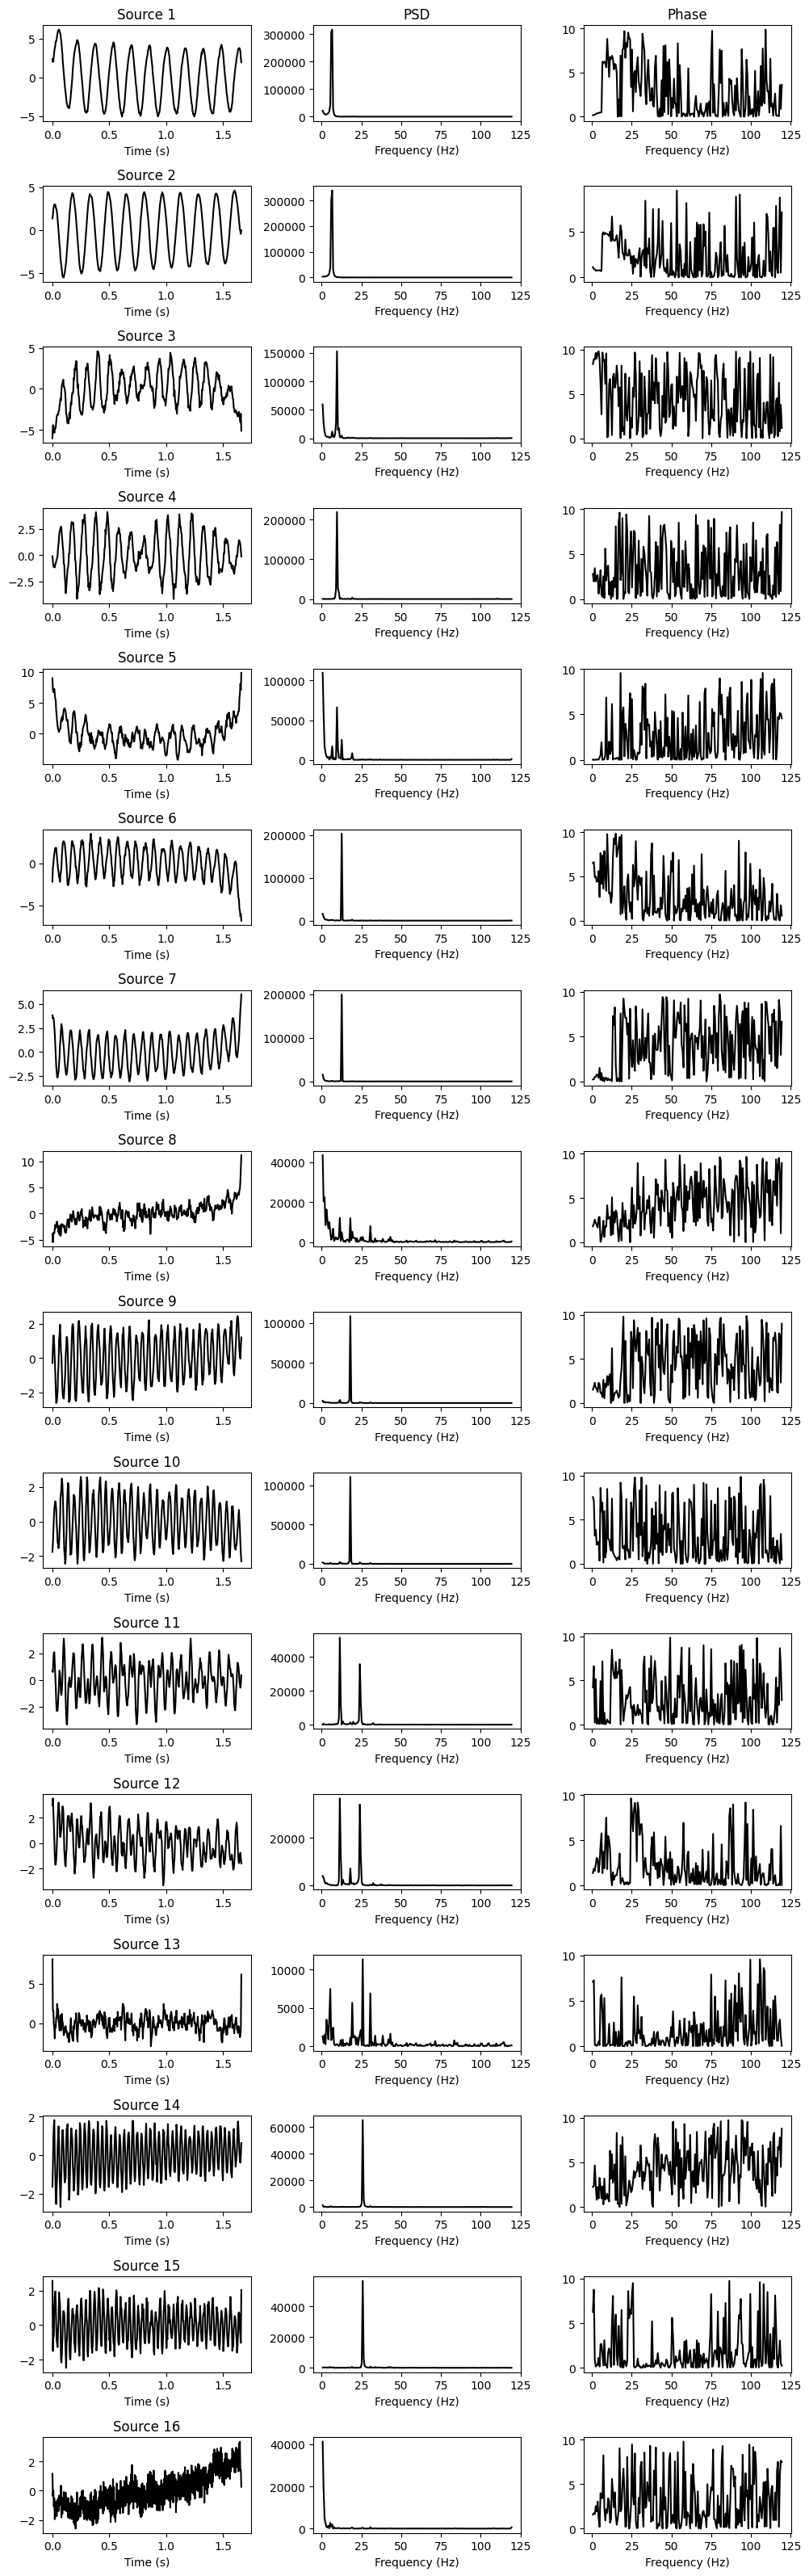

In [11]:
from marajomodes.visualization import plot
plot.plot_sources(t, freq, unmixed)
plt.show()

## Visualização: formas modais (espacial)

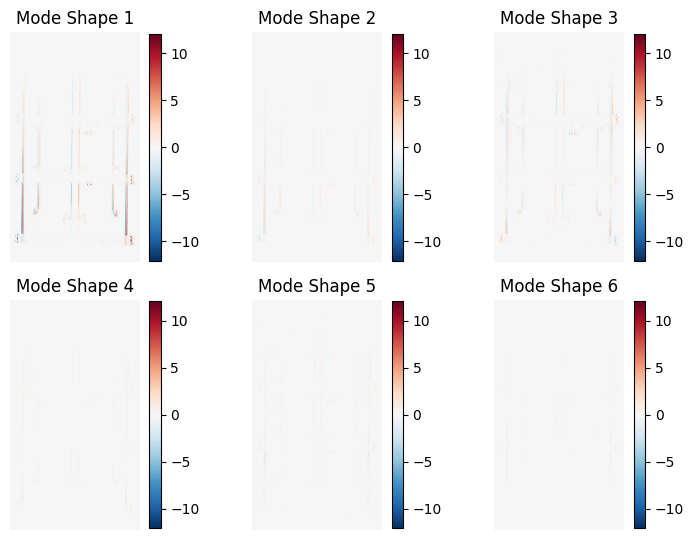

In [14]:
plot.plot_mode_shapes(mode_shapes, srcs, video.width, video.height)
plt.show()

## Visualização: coordenadas modais (tempo, PSD, fase)

<Figure size 640x480 with 0 Axes>

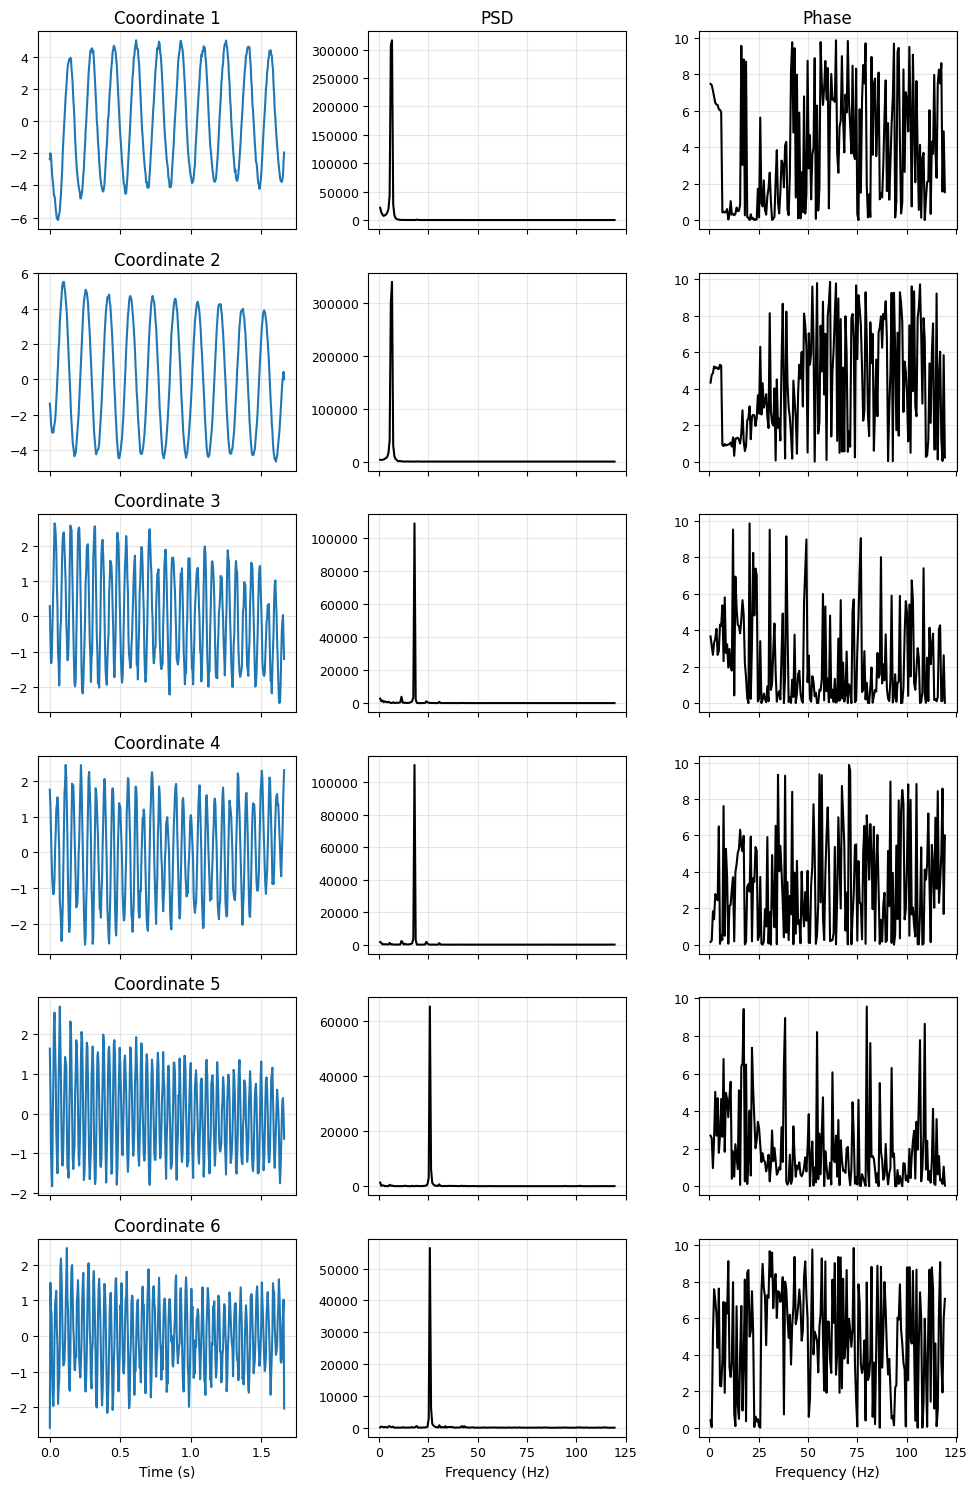

In [15]:
half = len(freq) - 1
fig = plt.figure()
numPC = 16
nFrames = video.frame_count
numSrc = len(srcs)

fig, axes = plt.subplots(numSrc, 3, figsize=(10, 2.5*numSrc), sharex='col')

half = nFrames // 2

for i in range(numSrc):

    signal = modal_coord[:, i]

    fft_vals = np.fft.fft(signal)
    psd = np.abs(fft_vals)**2
    phase = np.angle(fft_vals)**2   # keeping MATLAB behavior

    # --- Time coordinate ---
    axes[i, 0].plot(t, signal, lw=1.5)
    axes[i, 0].set_title(f"Coordinate {i+1}")
    axes[i, 0].tick_params(labelsize=9)
    axes[i, 0].grid(alpha=0.3)

    # --- PSD ---
    axes[i, 1].plot(freq[1:half], psd[1:half], lw=1.5, color='k')
    if i == 0:
        axes[i, 1].set_title("PSD")
    axes[i, 1].tick_params(labelsize=9)
    axes[i, 1].grid(alpha=0.3)

    # --- Phase ---
    axes[i, 2].plot(freq[1:half], phase[1:half], lw=1.5, color='k')
    if i == 0:
        axes[i, 2].set_title("Phase")
    axes[i, 2].tick_params(labelsize=9)
    axes[i, 2].grid(alpha=0.3)

# axis labels on bottom row
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Frequency (Hz)")
axes[-1, 2].set_xlabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

## Reconstrução do vídeo e taxa de compressão

Norm^2 (original - reconstruído): 0.02373694720062248


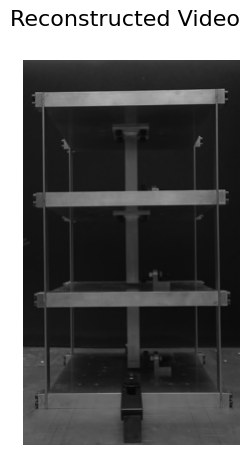

Compressão (modos vs vídeo): 0.8794


In [103]:
# Reconstrução: (n_frames, n_pixels) = mode_shapes @ modal_coord.T
reconstructed = (mode_shapes @ modal_coord.T).T  # (n_frames, n_pixels)
bckgd = mean.reshape(n_rows, n_cols)

error = np.zeros((n_rows, n_cols))
for j in range(n_frames):
    F0 = reconstructed[j, :].reshape(n_rows, n_cols) + bckgd
    error += frames[:, :, j].astype(float) - F0

norm_sq = np.sum(error.ravel()) ** 2
print("Norm^2 (original - reconstruído):", norm_sq)

# Taxa de compressão (apenas formas modais + coordenadas vs vídeo inteiro)
bytes_modes = modal_coord.nbytes + mode_shapes.nbytes
bytes_frames = frames.nbytes
# Render the reconstructed video
import matplotlib.animation as animation

fig_recon, ax_recon = plt.subplots(figsize=(5, 5))
im = ax_recon.imshow(np.zeros((n_rows, n_cols)), cmap='gray', vmin=0, vmax=255)
ax_recon.axis('off')
fig_recon.suptitle("Reconstructed Video", fontsize=16)

def update(frame_idx):
    frame_data = reconstructed[frame_idx, :].reshape(n_rows, n_cols) + bckgd
    im.set_array(np.clip(frame_data, 0, 255))
    return [im]

ani = animation.FuncAnimation(
    fig_recon, update, frames=n_frames, interval=1000/fps, blit=True, repeat=False
)
plt.show()

compression_rate = 1 - (bytes_modes / bytes_frames)
print(f"Compressão (modos vs vídeo): {compression_rate:.4f}")